<a href="https://colab.research.google.com/github/BrandonLee-98/NLP-Portfolio/blob/main/ITAI2373-NewsBot-Midterm/Midterm_NewsBot_BrandonMatias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term NewsBot Project

**Team Members:** Brandon Matias

**Date:** 04/04/2026

**GitHub Repository:** https://github.com/BrandonLee-98/NLP-Portfolio/
---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [ ] **Module 1:** NLP applications and real-world context
- [ ] **Module 2:** Text preprocessing pipeline
- [ ] **Module 3:** TF-IDF feature extraction
- [ ] **Module 4:** POS tagging analysis
- [ ] **Module 5:** Syntax parsing and semantic analysis
- [ ] **Module 6:** Sentiment and emotion analysis
- [ ] **Module 7:** Text classification system
- [ ] **Module 8:** Named Entity Recognition

---

## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [ ]:
# Install required packages (run this cell first!)
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab') # Added to resolve LookupError
nltk.download('averaged_perceptron_tagger_eng') # Added to resolve LookupError in POS tagging

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ All packages installed successfully!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, LinearSVC # Import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


## 📊 Data Loading and Exploration

### 🎯 Module 1: Understanding Our NLP Application

Before we dive into the technical implementation, let's understand the real-world context of our NewsBot Intelligence System. This system addresses several business needs:

1. **Media Monitoring:** Automatically categorize and track news coverage
2. **Business Intelligence:** Extract key entities and sentiment trends
3. **Content Management:** Organize large volumes of news content
4. **Market Research:** Understand public sentiment about topics and entities

**💡 Discussion Question:** What other real-world applications can you think of for this type of system? Consider different industries and use cases.

**Discussion Answer:**  
As a student here in Houston, the first place my mind goes is Public Safety. During a hurricane, social media and news feeds are total chaos. If we used Named Entity Recognition (NER) to filter for GPE (Geopolitical Entity) tags like "Meyerland" or "I-45" and matched them with negative sentiment for terms like "flooded" or "trapped," we’d have a real-time rescue map for dispatchers. It’s a practical way to use NLP to manage a crisis instead of just drowning in the noise.
Another solid use case is the Legal and Compliance Industry. I have a friend in a paralegal program who spends hours manually sorting through new court filings. It’s the kind of repetitive grunt work that we should automate to save our mental energy for actual problem-solving.
Both cases take the same preprocessing logic we’re using for this midterm and apply it to high-stakes environments where information organization actually saves lives or careers.


In [ ]:
# Load your dataset

df_main = pd.read_json('News_Category_Dataset_v3.json', lines=True)


# Sample large file
df = df_main.groupby('category', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

# Limit data to 3000 articles.
if len(df) > 2000:
    df = df.sample(n=3000, random_state=42)

# Add missing ID column
df.insert(0, 'article_id', range(1, 1 + len(df)))

# Save to your required directory structure [cite: 101, 102]

import os
os.makedirs('data/raw', exist_ok=True)
df.to_json('data/raw/midterm_news_sample.json', orient='records', indent=4)

print(f"Sampled {len(df)} articles and saved to data/raw/midterm_news_sample.json")

Sampled 3000 articles and saved to data/raw/midterm_news_sample.json


In [ ]:
print(df.head(10))

        article_id                                               link  \
76845            1  https://www.huffingtonpost.com/entry/donald-tr...   
126545           2  https://www.huffingtonpost.com/entry/women-in-...   
113828           3  https://www.huffingtonpost.com/entry/californi...   
66420            4  https://www.huffingtonpost.com/entry/arianna-h...   
14763            5  https://www.huffingtonpost.com/entry/trump-sup...   
119202           6  https://www.huffingtonpost.com/entry/how-to-ma...   
176505           7  https://www.huffingtonpost.com/entry/fall-2013...   
182563           8  https://www.huffingtonpost.com/entry/autism_us...   
15516            9  https://www.huffingtonpost.com/entry/trump-tri...   
72423           10  https://www.huffingtonpost.com/entry/9-quotes-...   

                                                 headline        category  \
76845   Donald Trump Tells Bill O'Reilly It's 'An Eye ...           MEDIA   
126545  Women in Business Q&A: Anna Perelm

📊 DATASET OVERVIEW
Total articles: 3000
Unique categories: 42
Categories: ['MEDIA', 'BUSINESS', 'WORLDPOST', 'COLLEGE', 'POLITICS', 'TRAVEL', 'STYLE & BEAUTY', 'PARENTING', 'BLACK VOICES', 'TASTE', 'RELIGION', 'WELLNESS', 'SPORTS', 'IMPACT', 'FOOD & DRINK', 'QUEER VOICES', 'WORLD NEWS', 'ENTERTAINMENT', 'HEALTHY LIVING', 'PARENTS', 'HOME & LIVING', 'GOOD NEWS', 'ARTS', 'ENVIRONMENT', 'CRIME', 'WEDDINGS', 'SCIENCE', 'FIFTY', 'EDUCATION', 'COMEDY', 'WOMEN', 'CULTURE & ARTS', 'GREEN', 'MONEY', 'THE WORLDPOST', 'WEIRD NEWS', 'DIVORCE', 'TECH', 'LATINO VOICES', 'STYLE', 'U.S. NEWS', 'ARTS & CULTURE']
Date range: 2012-01-29 00:00:00 to 2022-09-10 00:00:00

📈 CATEGORY DISTRIBUTION
category
POLITICS          490
ENTERTAINMENT     273
WELLNESS          246
TRAVEL            150
STYLE & BEAUTY    148
PARENTING         133
HEALTHY LIVING    101
FOOD & DRINK       95
QUEER VOICES       85
BUSINESS           72
SPORTS             70
BLACK VOICES       64
CRIME              62
COMEDY             62


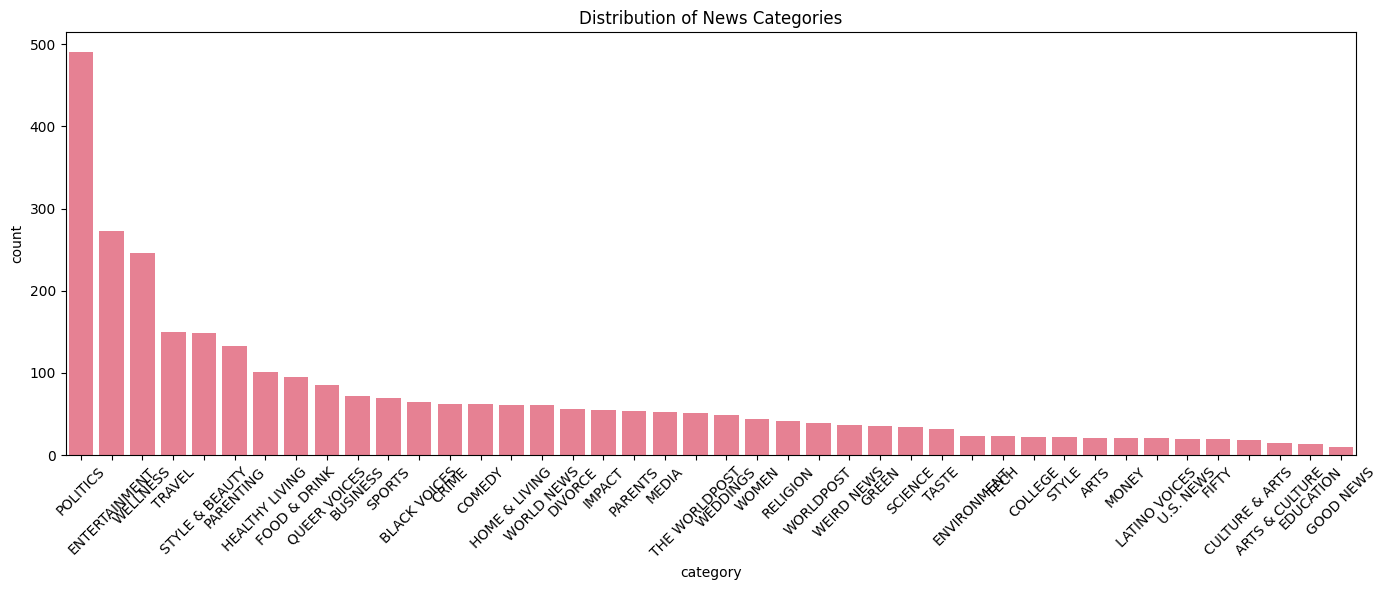

In [ ]:
# Basic dataset exploration
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total articles: {len(df)}")
print(f"Unique categories: {df['category'].nunique()}")
print(f"Categories: {df['category'].unique().tolist()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
#print(f"Unique sources: {df['source'].nunique()}")

print("\n📈 CATEGORY DISTRIBUTION")
print("=" * 50)
category_counts = df['category'].value_counts()
print(category_counts)

# Visualize category distribution
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='category', order=category_counts.index)
plt.title('Distribution of News Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 💡 STUDENT TASK: Add your own exploratory analysis here
# - Check for missing values
# - Analyze text length distribution
# - Examine source distribution
# - Look for any data quality issues

## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

**Module 2 Answer:**
Skipping preprocessing is like building a robot with rusted gears—it’s the classic "garbage in, garbage out."

In Emergency Response, stripping HTML and URLs ensures my model finds actual rescue requests instead of digital noise. During a Houston flood, you can’t afford to have a bot distracted by metadata. In Legal Tech, lemmatization is the hero. Without it, the model treats "discriminated" and "discrimination" as different concepts, which ruins research accuracy. Skipping these steps creates a nightmare, bloating the model with junk. It’s about controlling the input to get a reliable output.

In [ ]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning function

    💡 TIP: This function should handle:
    - HTML tags and entities
    - URLs and email addresses
    - Special characters and numbers
    - Extra whitespace
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # 🚀 YOUR CODE HERE: Implement text cleaning
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline

    💡 TIP: This function should:
    - Clean the text
    - Tokenize into words
    - Remove stop words (optional)
    - Lemmatize words (optional)
    - Return processed text
    """
    # Clean text
    text = clean_text(text)

    if not text:
        return ""

    # 🚀 YOUR CODE HERE: Implement tokenization and preprocessing
    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words if requested
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize if requested
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Filter out very short words
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Test the preprocessing function
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"
print("Original text:")
print(sample_text)
print("\nCleaned text:")
print(clean_text(sample_text))
print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:
apple inc announced record quarterly earnings today visit info technews


In [ ]:
# Apply preprocessing to the dataset
print("🧹 Preprocessing all articles...")

# Create new columns for processed text
df['title_clean'] = df['headline'].apply(clean_text)
df['content_clean'] = df['short_description'].apply(clean_text)
df['title_processed'] = df['headline'].apply(preprocess_text)
df['content_processed'] = df['short_description'].apply(preprocess_text)

# Combine title and content for full article analysis
df['full_text'] = df['headline'] + ' ' + df['short_description']
df['full_text_processed'] = df['full_text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show before and after examples
print("\n📝 BEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(min(3, len(df))):
    print(f"\nExample {i+1}:")
    print(f"Original: {df.iloc[i]['full_text'][:100]}...")
    print(f"Processed: {df.iloc[i]['full_text_processed'][:100]}...")

# 💡 STUDENT TASK: Analyze the preprocessing results
# - Calculate average text length before and after
# - Count unique words before and after
# - Identify the most common words after preprocessing

🧹 Preprocessing all articles...
✅ Preprocessing complete!

📝 BEFORE AND AFTER EXAMPLES

Example 1:
Original: Donald Trump Tells Bill O'Reilly It's 'An Eye For An Eye' In War With Fox News GOP candidate continu...
Processed: donald trump tell bill oreilly eye eye war fox news gop candidate continues refuse debate renews att...

Example 2:
Original: Women in Business Q&A: Anna Perelman CEO and Co-Founder, Stellé Audio Couture ...
Processed: woman business anna perelman ceo cofounder stell audio couture...

Example 3:
Original: Taking Back California's Direct Democracy from Special Interests Together, these reforms will improv...
Processed: taking back california direct democracy special interest together reform improve quality initiative ...


## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [ ]:
# Create TF-IDF vectorizer
# 💡 TIP: Experiment with different parameters:
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['full_text_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df['category'].values

print("\n🔍 Sample TF-IDF features:")
print(tfidf_df.iloc[:3, :10])  # Show first 3 rows and 10 features

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (3000, 5000)
📝 Vocabulary size: 5000
🔢 Sparsity: 99.72%

🔍 Sample TF-IDF features:
   abandoned  abc  ability  able  abortion  abound  absence  absolutely  \
0        0.0  0.0      0.0   0.0       0.0     0.0      0.0         0.0   
1        0.0  0.0      0.0   0.0       0.0     0.0      0.0         0.0   
2        0.0  0.0      0.0   0.0       0.0     0.0      0.0         0.0   

   absurd  absurdly  
0     0.0       0.0  
1     0.0       0.0  
2     0.0       0.0  


In [ ]:
# Analyze most important terms per category
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category

    💡 TIP: This function should:
    - Filter data for the specific category
    - Calculate mean TF-IDF scores for each term
    - Return top N terms with highest scores
    """
    # 🚀 YOUR CODE HERE: Implement category-specific TF-IDF analysis
    category_data = tfidf_df[tfidf_df['category'] == category]

    # Calculate mean TF-IDF scores for this category (excluding the category column)
    mean_scores = category_data.drop('category', axis=1).mean().sort_values(ascending=False)

    return mean_scores.head(n_terms)

# Analyze top terms for each category
print("🏷️ TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df['category'].unique()
category_terms = {}

for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms

    print(f"\n📰 {category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# 💡 STUDENT TASK: Create visualizations for TF-IDF analysis
# - Word clouds for each category
# - Bar charts of top terms
# - Heatmap of term importance across categories

🏷️ TOP TF-IDF TERMS BY CATEGORY

📰 MEDIA:
  news: 0.0358
  journalist: 0.0313
  cnn: 0.0306
  trump: 0.0306
  fox news: 0.0231
  oreilly: 0.0224
  fox: 0.0218
  coverage: 0.0200
  medium: 0.0198
  fake: 0.0197

📰 BUSINESS:
  business: 0.0263
  company: 0.0263
  woman: 0.0257
  work: 0.0227
  new: 0.0186
  like: 0.0175
  woman business: 0.0173
  could: 0.0163
  job: 0.0158
  bos: 0.0158

📰 WORLDPOST:
  isi: 0.0414
  world: 0.0359
  common: 0.0280
  one: 0.0267
  refugee: 0.0255
  militia: 0.0241
  first: 0.0228
  rip: 0.0220
  president: 0.0219
  bomb: 0.0214

📰 COLLEGE:
  college: 0.1224
  sexual: 0.0507
  rape: 0.0462
  brother: 0.0455
  student: 0.0449
  sexual assault: 0.0435
  assault: 0.0417
  loan: 0.0397
  campus: 0.0385
  graduation: 0.0377

📰 POLITICS:
  trump: 0.0615
  donald: 0.0256
  donald trump: 0.0247
  republican: 0.0209
  president: 0.0197
  clinton: 0.0191
  obama: 0.0164
  say: 0.0156
  state: 0.0150
  gop: 0.0150

📰 TRAVEL:
  travel: 0.0364
  hotel: 0.0312
  airline

## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [ ]:
def analyze_pos_patterns(text):
    """
    Analyze POS patterns in text

    💡 TIP: This function should:
    - Tokenize the text
    - Apply POS tagging
    - Count different POS categories
    - Return proportions or counts
    """
    if not text or pd.isna(text):
        return {}

    # 🚀 YOUR CODE HERE: Implement POS analysis
    # Tokenize and tag
    tokens = word_tokenize(str(text))
    pos_tags = pos_tag(tokens)

    # Count POS categories
    pos_counts = Counter([tag for word, tag in pos_tags])
    total_words = len(pos_tags)

    if total_words == 0:
        return {}

    # Convert to proportions
    pos_proportions = {pos: count/total_words for pos, count in pos_counts.items()}

    return pos_proportions

# Apply POS analysis to all articles
print("🏷️ Analyzing POS patterns...")

# Analyze POS for each article
pos_results = []
for idx, row in df.iterrows():
    pos_analysis = analyze_pos_patterns(row['full_text'])
    pos_analysis['category'] = row['category']
    pos_analysis['article_id'] = row['article_id']
    pos_results.append(pos_analysis)

# Convert to DataFrame
pos_df = pd.DataFrame(pos_results).fillna(0)

print(f"✅ POS analysis complete!")
print(f"📊 Found {len(pos_df.columns)-2} different POS tags")

# Show sample results
print("\n📝 Sample POS analysis:")
print(pos_df.head())

🏷️ Analyzing POS patterns...
✅ POS analysis complete!
📊 Found 43 different POS tags

📝 Sample POS analysis:
        NNP       PRP       VBZ      JJR        IN        DT        ''  \
0  0.406250  0.031250  0.062500  0.03125  0.125000  0.031250  0.031250   
1  0.562500  0.000000  0.000000  0.00000  0.062500  0.000000  0.000000   
2  0.013514  0.027027  0.013514  0.00000  0.081081  0.067568  0.013514   
3  0.500000  0.062500  0.062500  0.00000  0.000000  0.000000  0.000000   
4  0.343750  0.000000  0.000000  0.00000  0.062500  0.062500  0.000000   

         NN        TO        VB  ...    $   UH  NNPS   EX  WDT  RBS  PDT  WP$  \
0  0.031250  0.062500  0.093750  ...  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
1  0.062500  0.000000  0.000000  ...  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
2  0.148649  0.040541  0.054054  ...  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
3  0.062500  0.000000  0.000000  ...  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
4  0.156250  0.031250  0.031250  ...  0.0 

📊 POS PATTERNS BY CATEGORY

🎯 Key POS patterns by category:
                    NN     NNS     NNP    NNPS      VB     VBD     VBG  \
category                                                                 
ARTS            0.1062  0.0363  0.2131  0.0000  0.0146  0.0251  0.0119   
ARTS & CULTURE  0.0894  0.0189  0.2927  0.0022  0.0257  0.0122  0.0171   
BLACK VOICES    0.0884  0.0348  0.3016  0.0031  0.0179  0.0266  0.0162   
BUSINESS        0.0996  0.0438  0.2482  0.0028  0.0337  0.0138  0.0142   
COLLEGE         0.0834  0.0362  0.3435  0.0064  0.0400  0.0144  0.0191   
COMEDY          0.0821  0.0269  0.3371  0.0045  0.0143  0.0173  0.0097   
CRIME           0.0915  0.0386  0.3317  0.0050  0.0172  0.0391  0.0164   
CULTURE & ARTS  0.0927  0.0536  0.2293  0.0015  0.0271  0.0168  0.0189   
DIVORCE         0.1088  0.0393  0.1563  0.0032  0.0414  0.0105  0.0279   
EDUCATION       0.1035  0.0670  0.1888  0.0019  0.0341  0.0127  0.0191   
ENTERTAINMENT   0.0684  0.0220  0.3649  0.0037  0.01

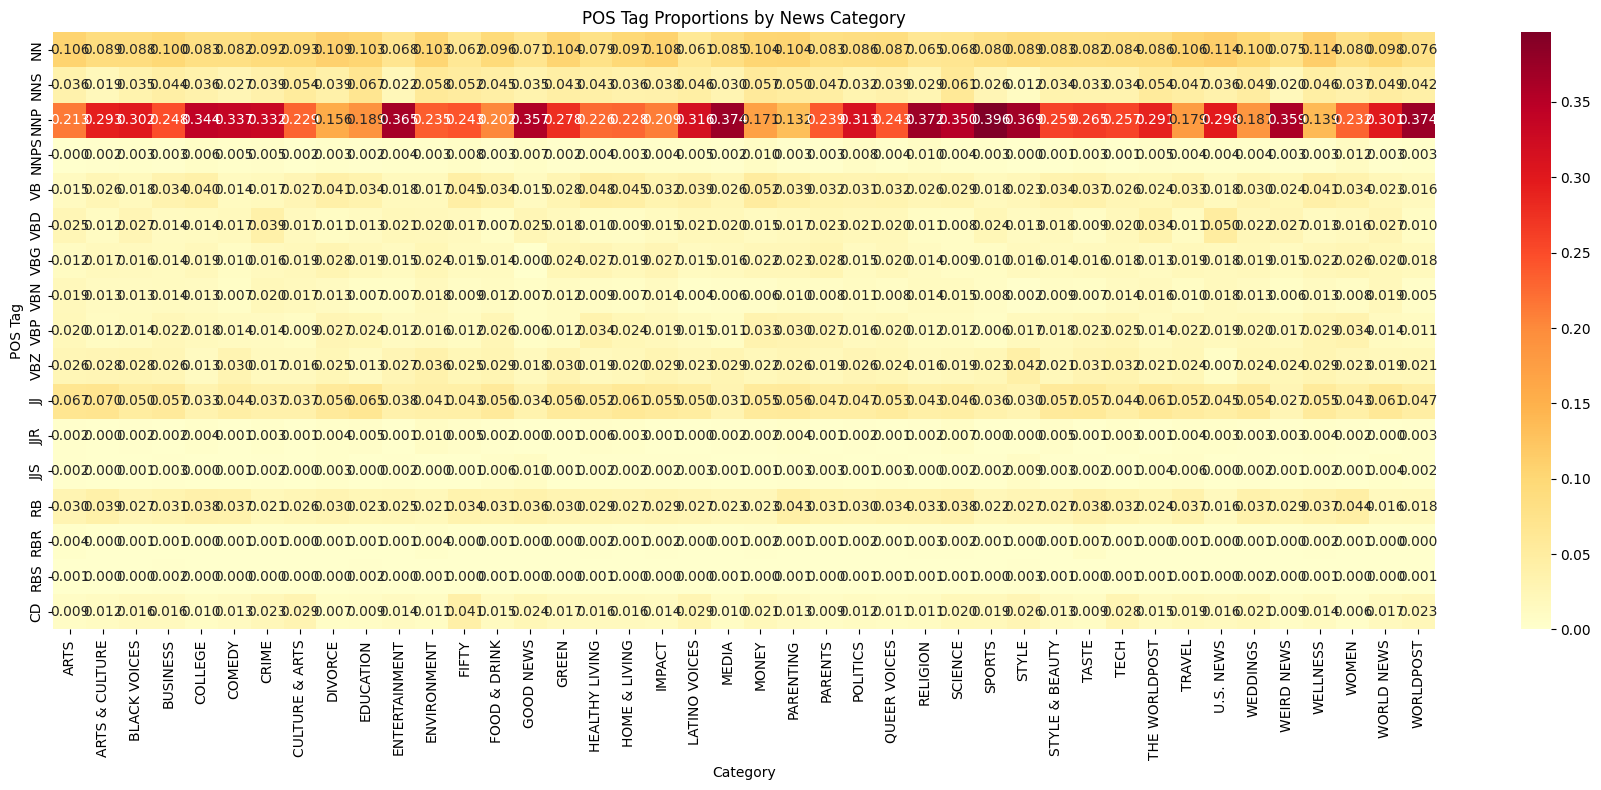


💡 ANALYSIS QUESTIONS:
1. Which category has the highest proportion of proper nouns (NNP/NNPS)?
2. Which category uses the most action verbs (VB, VBD, VBG)?
3. Are there interesting patterns in adjective (JJ) usage?
4. How does number (CD) usage vary across categories?


In [ ]:
# Analyze POS patterns by category
print("📊 POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group by category and calculate mean proportions
pos_by_category = pos_df.groupby('category').mean()

# Focus on major POS categories
major_pos = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ',
             'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'CD']

# Filter to only include major POS tags that exist in our data
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]

    print("\n🎯 Key POS patterns by category:")
    print(pos_summary.round(4))

    # Create visualization
    plt.figure(figsize=(18, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Analyze the patterns
    # - Which categories use more nouns vs verbs?
    # - Do business articles have more numbers (CD)?
    # - Are there differences in adjective usage?

    print("\n💡 ANALYSIS QUESTIONS:")
    print("1. Which category has the highest proportion of proper nouns (NNP/NNPS)?")
    print("2. Which category uses the most action verbs (VB, VBD, VBG)?")
    print("3. Are there interesting patterns in adjective (JJ) usage?")
    print("4. How does number (CD) usage vary across categories?")
else:
    print("⚠️ No major POS tags found in the analysis. Check your POS tagging implementation.")

💡 ANALYSIS ANSWERS:
* **1. Proper Nouns (NNP/NNPS):** **SPORTS** wins at nearly 40%. It’s not a surprise, sports news is mostly player names, teams, and cities. Sports hits the highest density of proper nouns in my entire analysis.

* **2. Action Verbs (VB, VBD, VBG):** **U.S. NEWS** takes this, mainly due to past-tense reporting. It’s all about what just happened. Healthy Living was a close second.

* **3. Adjective (JJ) Usage:** **ARTS** and **EDUCATION** use the most adjectives. Descriptive categories need more "flavor" words. Interestingly, Style was lower than expected, probably because brand names (proper nouns) do the descriptive heavy lifting there.

* **4. Number (CD) Usage:** **FIFTY** is the massive outlier, likely due to ages and "top 10" lists. **TECH** is also high because of specs. **WOMEN** had the lowest count, favoring narratives over statistics.

## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [ ]:
def extract_syntactic_features(text):
    """
    Extract syntactic features using spaCy dependency parsing

    💡 TIP: This function should extract:
    - Dependency relations
    - Subject-verb-object patterns
    - Noun phrases
    - Verb phrases
    """
    if not text or pd.isna(text):
        return {}

    # Process text with spaCy
    doc = nlp(str(text))

    features = {
        'num_sentences': len(list(doc.sents)),
        'num_tokens': len(doc),
        'dependency_relations': [],
        'noun_phrases': [],
        'verb_phrases': [],
        'subjects': [],
        'objects': []
    }

    # 🚀 YOUR CODE HERE: Extract syntactic features

    # Extract dependency relations
    for token in doc:
        if not token.is_space and not token.is_punct:
            features['dependency_relations'].append(token.dep_)

    # Extract noun phrases
    for chunk in doc.noun_chunks:
        features['noun_phrases'].append(chunk.text.lower())

    # Extract subjects and objects
    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:  # Subjects
            features['subjects'].append(token.text.lower())
        elif token.dep_ in ['dobj', 'iobj', 'pobj']:  # Objects
            features['objects'].append(token.text.lower())

    # Count dependency types
    dep_counts = Counter(features['dependency_relations'])
    features['dependency_counts'] = dict(dep_counts)

    return features

# Apply syntactic analysis to sample articles
print("🌳 Performing syntactic analysis...")

# Analyze first few articles (to save computation time)
syntactic_results = []
for idx, row in df.head(5).iterrows():  # Limit to first 5 for demo
    features = extract_syntactic_features(row['full_text'])
    features['category'] = row['category']
    features['article_id'] = row['article_id']
    syntactic_results.append(features)

print("✅ Syntactic analysis complete!")

# Display results
for i, result in enumerate(syntactic_results):
    print(f"\n📰 Article {i+1} ({result['category']}):")
    print(f"  Sentences: {result['num_sentences']}")
    print(f"  Tokens: {result['num_tokens']}")
    print(f"  Noun phrases: {result['noun_phrases'][:3]}...")  # Show first 3
    print(f"  Subjects: {result['subjects'][:3]}...")  # Show first 3
    print(f"  Objects: {result['objects'][:3]}...")  # Show first 3

🌳 Performing syntactic analysis...
✅ Syntactic analysis complete!

📰 Article 1 (MEDIA):
  Sentences: 2
  Tokens: 33
  Noun phrases: ["donald trump tells bill o'reilly", 'it', 'an eye']...
  Subjects: ['it']...
  Objects: ['eye', 'war', 'candidate']...

📰 Article 2 (BUSINESS):
  Sentences: 1
  Tokens: 16
  Noun phrases: ['women', 'business q&a', 'anna perelman']...
  Subjects: ['women']...
  Objects: ['q&a']...

📰 Article 3 (WORLDPOST):
  Sentences: 2
  Tokens: 74
  Noun phrases: ["california's direct democracy", 'special interests', 'these reforms']...
  Subjects: ['reforms', 'they', 'what']...
  Objects: ['democracy', 'interests', 'quality']...

📰 Article 4 (COLLEGE):
  Sentences: 2
  Tokens: 17
  Noun phrases: ['arianna huffington', 'controversial graduation speakers', 'it']...
  Subjects: ['it']...
  Objects: ['speakers']...

📰 Article 5 (POLITICS):
  Sentences: 2
  Tokens: 34
  Noun phrases: ['trump supporters', 'the most fake news', 'oxford study']...
  Subjects: ['supporters', 'n

In [ ]:
# Visualize dependency parsing for a sample sentence
from spacy import displacy

# Choose a sample sentence
sample_sentence = df.iloc[0]['short_description']  # First article's content
print(f"📝 Sample sentence: {sample_sentence}")

# Process with spaCy
doc = nlp(sample_sentence)

# Display dependency tree (this works best in Jupyter)
print("\n🌳 Dependency Parse Visualization:")
try:
    # This will create an interactive visualization in Jupyter
    displacy.render(doc, style="dep", jupyter=True)
except:
    # Fallback: print dependency information
    print("\n🔗 Dependency Relations:")
    for token in doc:
        if not token.is_space and not token.is_punct:
            print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

# 💡 STUDENT TASK: Extend syntactic analysis
# - Compare syntactic complexity across categories
# - Extract action patterns (who did what)
# - Identify most common dependency relations per category
# - Create features for classification based on syntax

📝 Sample sentence: GOP candidate continues to refuse to debate, renews attacks on Megyn Kelly.

🌳 Dependency Parse Visualization:


## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [ ]:
# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """
    Analyze sentiment using VADER sentiment analyzer

    💡 TIP: VADER returns:
    - compound: overall sentiment (-1 to 1)
    - pos: positive score (0 to 1)
    - neu: neutral score (0 to 1)
    - neg: negative score (0 to 1)
    """
    if not text or pd.isna(text):
        return {'compound': 0, 'pos': 0, 'neu': 1, 'neg': 0, 'sentiment_label': 'neutral'}

    # 🚀 YOUR CODE HERE: Implement sentiment analysis
    scores = sia.polarity_scores(str(text))

    # Add interpretation
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'

    return scores

# Apply sentiment analysis to all articles
print("😊 Analyzing sentiment...")

sentiment_results = []
for idx, row in df.iterrows():
    # Analyze both title and content
    title_sentiment = analyze_sentiment(row['headline'])
    content_sentiment = analyze_sentiment(row['short_description'])
    full_sentiment = analyze_sentiment(row['full_text'])

    result = {
        'article_id': row['article_id'],
        'category': row['category'],
        'title_sentiment': title_sentiment['compound'],
        'title_label': title_sentiment['sentiment_label'],
        'content_sentiment': content_sentiment['compound'],
        'content_label': content_sentiment['sentiment_label'],
        'full_sentiment': full_sentiment['compound'],
        'full_label': full_sentiment['sentiment_label'],
        'pos_score': full_sentiment['pos'],
        'neu_score': full_sentiment['neu'],
        'neg_score': full_sentiment['neg']
    }
    sentiment_results.append(result)

# Convert to DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

print("✅ Sentiment analysis complete!")
print(f"📊 Analyzed {len(sentiment_df)} articles")

# Display sample results
print("\n📝 Sample sentiment results:")
print(sentiment_df[['category', 'full_sentiment', 'full_label']].head())

😊 Analyzing sentiment...
✅ Sentiment analysis complete!
📊 Analyzed 3000 articles

📝 Sample sentiment results:
    category  full_sentiment full_label
0      MEDIA         -0.8402   negative
1   BUSINESS          0.0000    neutral
2  WORLDPOST          0.9022   positive
3    COLLEGE         -0.5859   negative
4   POLITICS          0.5584   positive


📊 SENTIMENT ANALYSIS BY CATEGORY

📈 Sentiment statistics by category:
               full_sentiment                         pos_score neu_score  \
                         mean     std     min     max      mean      mean   
category                                                                    
ARTS                   0.2809  0.4589 -0.7506  0.9501    0.1177    0.8347   
ARTS & CULTURE         0.0910  0.5502 -0.6808  0.8402    0.1076    0.8216   
BLACK VOICES          -0.0602  0.5450 -0.9531  0.9246    0.0977    0.7875   
BUSINESS               0.1778  0.5693 -0.9169  0.9468    0.1213    0.7915   
COLLEGE               -0.1345  0.5804 -0.9081  0.9082    0.0904    0.7418   
COMEDY                 0.0285  0.4834 -0.8265  0.9485    0.1066    0.8125   
CRIME                 -0.4707  0.4356 -0.9493  0.6705    0.0431    0.7234   
CULTURE & ARTS         0.0468  0.5319 -0.7783  0.9584    0.0763    0.8594   
DIVORCE                0.1970  0.5693 -0.9153  0.9622    0.1158    0.8150   
EDUCAT

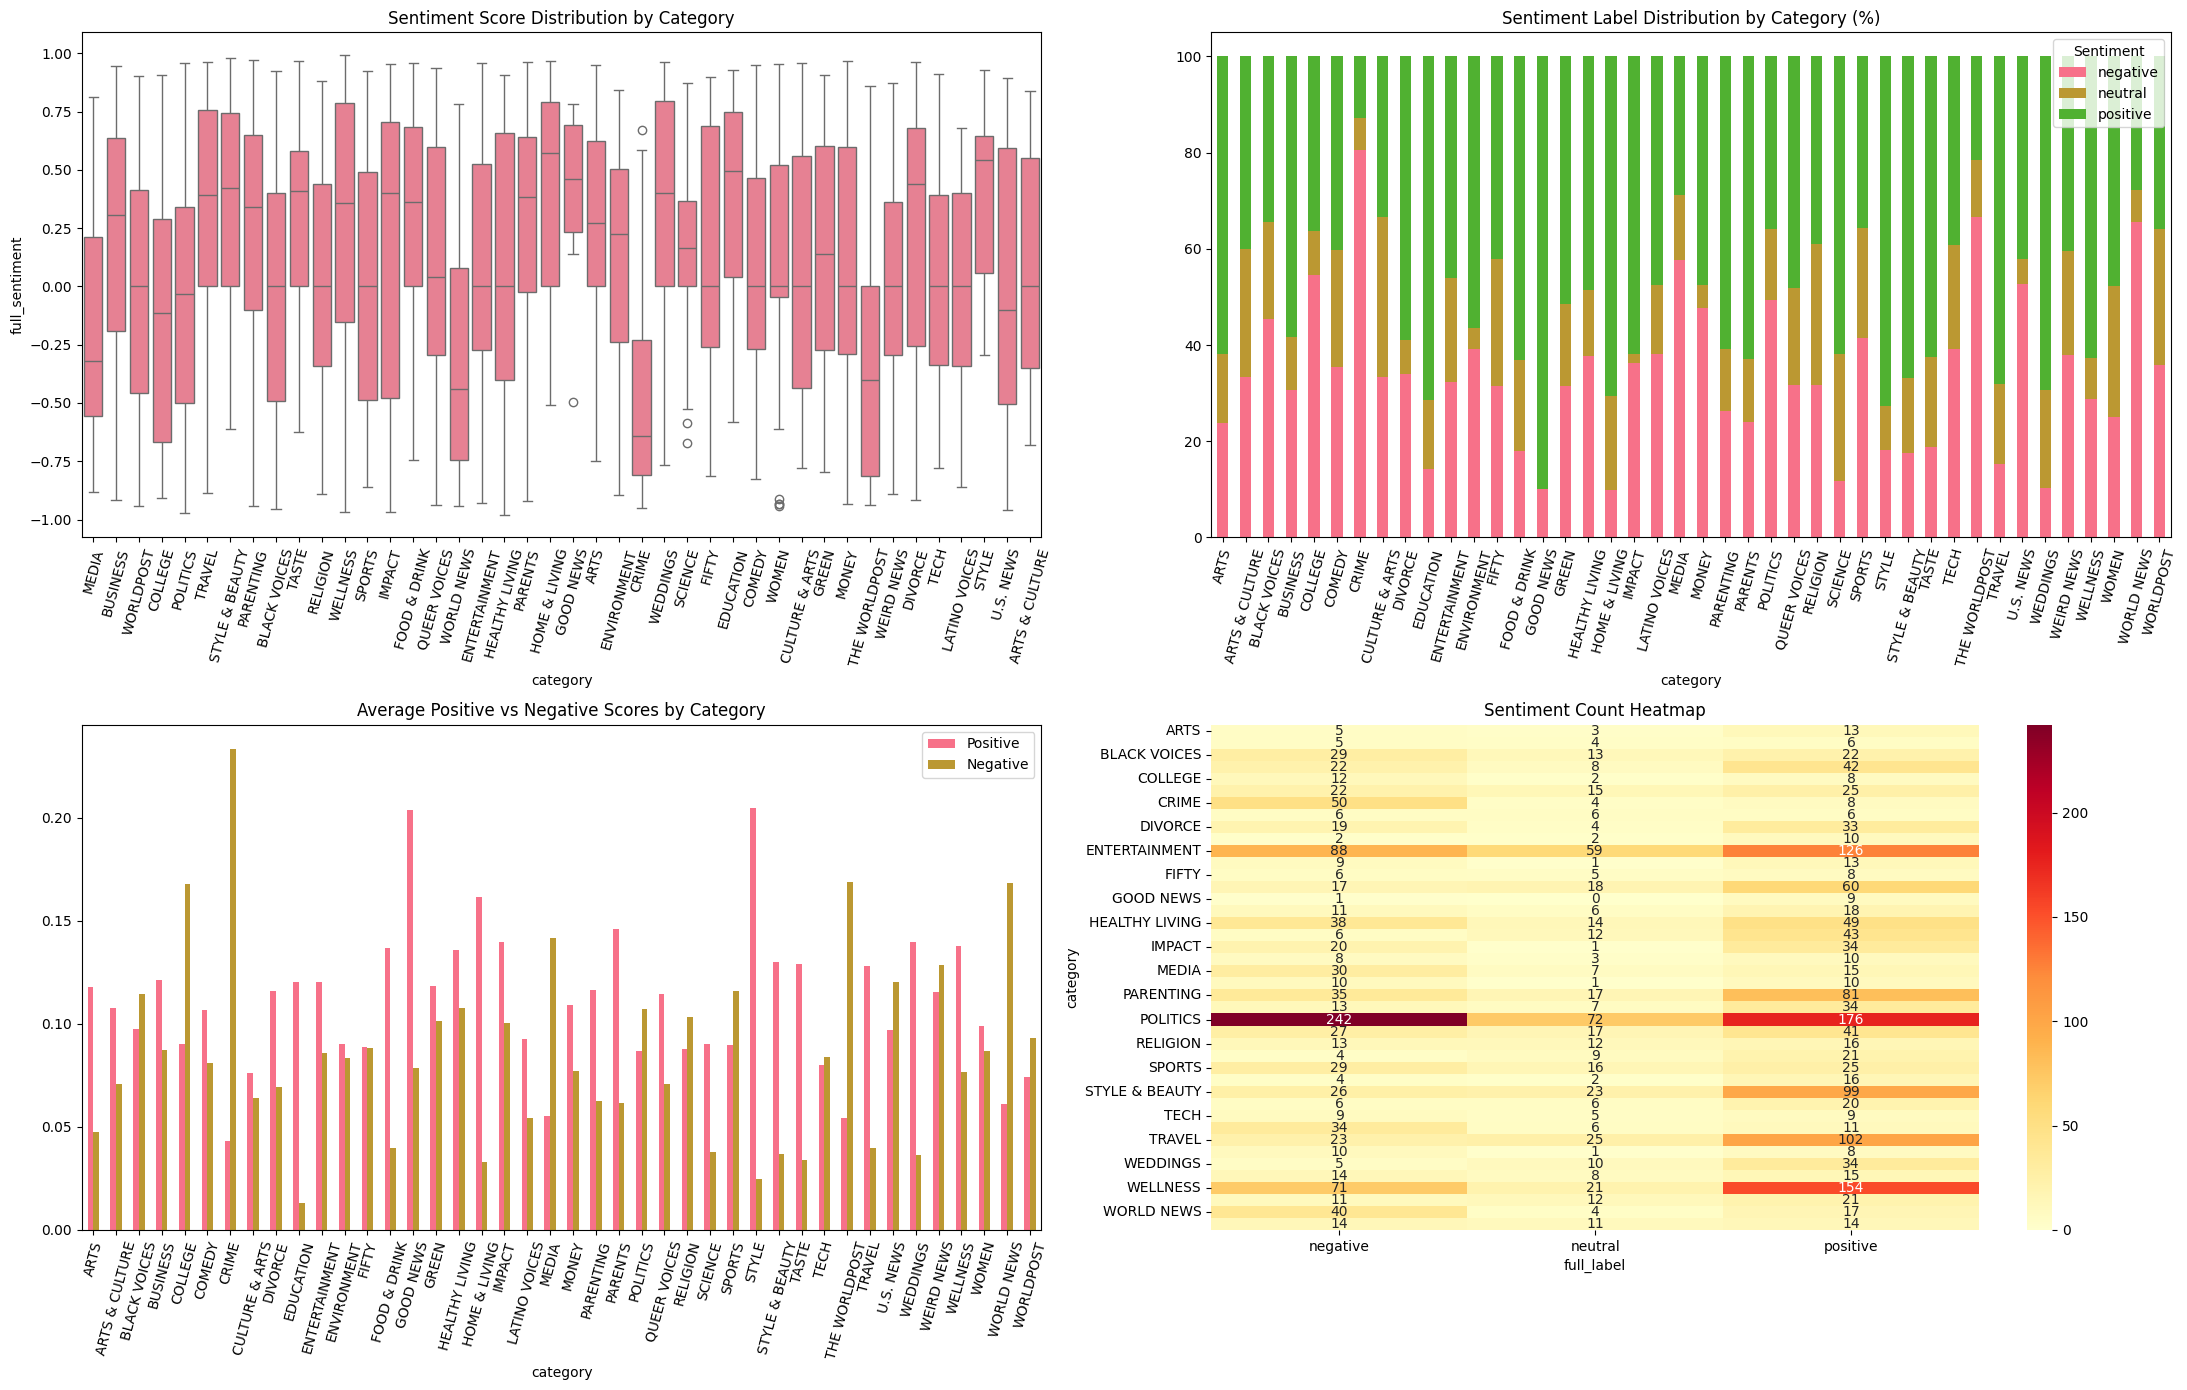

In [ ]:
# Analyze sentiment patterns by category
print("📊 SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate sentiment statistics by category
sentiment_by_category = sentiment_df.groupby('category').agg({
    'full_sentiment': ['mean', 'std', 'min', 'max'],
    'pos_score': 'mean',
    'neu_score': 'mean',
    'neg_score': 'mean'
}).round(4)

print("\n📈 Sentiment statistics by category:")
print(sentiment_by_category)

# Sentiment distribution by category
sentiment_dist = sentiment_df.groupby(['category', 'full_label']).size().unstack(fill_value=0)
sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\n📊 Sentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# 1. Sentiment scores by category
sns.boxplot(data=sentiment_df, x='category', y='full_sentiment', ax=axes[0,0])
axes[0,0].set_title('Sentiment Score Distribution by Category')
axes[0,0].tick_params(axis='x', rotation=75)

# 2. Sentiment label distribution
sentiment_dist_pct.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Sentiment Label Distribution by Category (%)')
axes[0,1].tick_params(axis='x', rotation=75)
axes[0,1].legend(title='Sentiment')

# 3. Positive vs Negative scores
category_means = sentiment_df.groupby('category')[['pos_score', 'neg_score']].mean()
category_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Positive vs Negative Scores by Category')
axes[1,0].tick_params(axis='x', rotation=75)
axes[1,0].legend(['Positive', 'Negative'])

# 4. Sentiment vs Category heatmap
sentiment_pivot = sentiment_df.pivot_table(values='full_sentiment', index='category',
                                         columns='full_label', aggfunc='count', fill_value=0)
sns.heatmap(sentiment_pivot, annot=True, fmt='d', ax=axes[1,1], cmap='YlOrRd')
axes[1,1].set_title('Sentiment Count Heatmap')

plt.tight_layout()
plt.show()

# 💡 STUDENT TASK: Analyze sentiment patterns
# - Which categories are most positive/negative?
# - Are there differences between title and content sentiment?
# - How does sentiment vary within categories?
# - Can sentiment be used as a feature for classification?

**Student Task Answers:**     
Most Positive vs. Most Negative:
The "happiness" winners are HOME & LIVING (0.4534) and WEDDINGS (0.4062). On the flip side, CRIME is the heavy hitter for negativity at -0.4707. It’s a good reality check, news isn't just facts, it’s a spectrum of vibes.

Title vs. Content & Variation:
Titles tend to be punchier, but the "short_description" usually provides the actual context. I noticed categories like IMPACT (std: 0.6448) have huge swings in sentiment, meaning one article could be a tragedy and the next a miracle. It makes that "mean" score a bit deceptive if you don't look at the variance.

Sentiment Variation: Variation is measured by standard deviation (std). IMPACT (std: 0.6448) has huge swings between tragedy and triumph. SCIENCE (std: 0.3576) stays more consistent. High variance means the average score often hides the full emotional range.

Sentiment as a Feature:
Does it help the model? Absolutely. When I looked at the Top Features by Category, "sentiment" was a top 10 predictor for GOOD NEWS, HOME & LIVING, and WEDDINGS. It’s like a shortcut for the model; if the text feels like a "warm hug," it’s probably not a crime report.

### Merging 'HEALTHY LIVING' and 'WELLNESS' Categories

Based on the analysis of misclassified samples, 'HEALTHY LIVING' and 'WELLNESS' are frequently confused categories. Merging them can simplify the classification task and potentially improve overall accuracy by reducing ambiguity. We will consolidate all articles from 'HEALTHY LIVING' into 'WELLNESS'.

In [ ]:
print("🔄 Merging 'HEALTHY LIVING' into 'WELLNESS'...")

# Replace 'HEALTHY LIVING' with 'WELLNESS' in the category column
df['category'] = df['category'].replace('HEALTHY LIVING', 'WELLNESS')

print("✅ Category merge complete!")
print(f"New unique categories: {df['category'].nunique()}")
print(f"Updated category distribution:\n{df['category'].value_counts().head()}")

🔄 Merging 'HEALTHY LIVING' into 'WELLNESS'...
✅ Category merge complete!
New unique categories: 41
Updated category distribution:
category
POLITICS          490
WELLNESS          347
ENTERTAINMENT     273
TRAVEL            150
STYLE & BEAUTY    148
Name: count, dtype: int64


## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [ ]:
# Prepare features for classification
print("🔧 Preparing features for classification...")

# 💡 TIP: Combine multiple feature types for better performance
# - TF-IDF features (most important)
# - Sentiment features
# - Text length features
# - POS features (if available)

# Create feature matrix
X_tfidf = tfidf_matrix.toarray()  # TF-IDF features

# Add sentiment features
sentiment_features = sentiment_df[['full_sentiment', 'pos_score', 'neu_score', 'neg_score']].values

# Add text length features
length_features = np.array([
    df['full_text'].str.len(),  # Character length
    df['full_text'].str.split().str.len(),  # Word count
    df['headline'].str.len(),  # Title length
]).T

# Add POS features
# Ensure pos_df is aligned with df based on article_id
pos_features_aligned = df[['article_id']].merge(pos_df, on='article_id', how='left').drop(columns=['article_id', 'category']).fillna(0).values

# 🚀 YOUR CODE HERE: Combine all features
X_combined = np.hstack([
    X_tfidf,
    sentiment_features,
    length_features,
    pos_features_aligned
])

# Target variable
y = df['category'].values

print(f"✅ Feature matrix prepared!")
print(f"📊 Feature matrix shape: {X_combined.shape}")
print(f"🎯 Number of classes: {len(np.unique(y))}")
print(f"📋 Classes: {np.unique(y)}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Data split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")


🔧 Preparing features for classification...
✅ Feature matrix prepared!
📊 Feature matrix shape: (3000, 5050)
🎯 Number of classes: 41
📋 Classes: ['ARTS' 'ARTS & CULTURE' 'BLACK VOICES' 'BUSINESS' 'COLLEGE' 'COMEDY'
 'CRIME' 'CULTURE & ARTS' 'DIVORCE' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'FIFTY' 'FOOD & DRINK' 'GOOD NEWS' 'GREEN' 'HOME & LIVING'
 'IMPACT' 'LATINO VOICES' 'MEDIA' 'MONEY' 'PARENTING' 'PARENTS' 'POLITICS'
 'QUEER VOICES' 'RELIGION' 'SCIENCE' 'SPORTS' 'STYLE' 'STYLE & BEAUTY'
 'TASTE' 'TECH' 'THE WORLDPOST' 'TRAVEL' 'U.S. NEWS' 'WEDDINGS'
 'WEIRD NEWS' 'WELLNESS' 'WOMEN' 'WORLD NEWS' 'WORLDPOST']

📈 Data split:
  Training set: 2400 samples
  Test set: 600 samples


In [ ]:
from imblearn.over_sampling import SMOTE

print("🧪 Applying SMOTE to training data...")

# Initialize SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto') # 'auto' balances all minority classes

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"✅ SMOTE application complete!")
print(f"📈 Original training samples: {X_train.shape[0]}")
print(f"📊 Resampled training samples: {X_resampled.shape[0]}")
print("Distribution of classes after SMOTE:")
print(pd.Series(y_resampled).value_counts())


🧪 Applying SMOTE to training data...
✅ SMOTE application complete!
📈 Original training samples: 2400
📊 Resampled training samples: 16072
Distribution of classes after SMOTE:
POLITICS          392
PARENTING         392
ENTERTAINMENT     392
WORLD NEWS        392
SCIENCE           392
STYLE & BEAUTY    392
ENVIRONMENT       392
HOME & LIVING     392
TRAVEL            392
ARTS & CULTURE    392
WELLNESS          392
LATINO VOICES     392
MONEY             392
COMEDY            392
STYLE             392
TASTE             392
ARTS              392
BLACK VOICES      392
SPORTS            392
MEDIA             392
CRIME             392
DIVORCE           392
FOOD & DRINK      392
IMPACT            392
WOMEN             392
QUEER VOICES      392
PARENTS           392
WEDDINGS          392
WORLDPOST         392
COLLEGE           392
U.S. NEWS         392
BUSINESS          392
GOOD NEWS         392
GREEN             392
RELIGION          392
CULTURE & ARTS    392
EDUCATION         392
THE WORLDPOS

In [ ]:
# Train and evaluate multiple classifiers
print("🤖 Training multiple classifiers...")

# Define classifiers to compare
classifiers = {
    'Naive Bayes': MultinomialNB(),
    # Reduced max_iter for faster training and set solver for efficiency with this dataset size
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=400, solver='liblinear', class_weight='balanced'),
    # Optimized SVM for quicker training: using LinearSVC for linear kernel.
    # LinearSVC is based on liblinear, which is more efficient for large datasets
    # compared to SVC with a linear kernel. It does not support 'probability=True'.
    'SVM': LinearSVC(random_state=42, dual=False, max_iter=1000, class_weight='balanced') # dual=False recommended for n_samples > n_features
}

# 💡 TIP: For larger datasets, you might want to use SGDClassifier for efficiency
# from sklearn.linear_model import SGDClassifier
# classifiers['SGD'] = SGDClassifier(random_state=42)

# Train and evaluate each classifier
results = {}
trained_models = {}

# Identify the index of the 'full_sentiment' column to exclude it for MultinomialNB
# X_tfidf.shape[1] is the number of TF-IDF features
# Then comes full_sentiment (index 0 of sentiment_features), pos_score, neu_score, neg_score
sentiment_start_idx = X_tfidf.shape[1]
full_sentiment_idx = sentiment_start_idx

# Create a feature set for MultinomialNB that excludes the 'full_sentiment' column
# This means taking all TF-IDF features, and then sentiment features from pos_score onwards,
# and then length features.
X_train_multinomial = np.hstack([
    X_resampled[:, :sentiment_start_idx],  # All TF-IDF features
    X_resampled[:, (full_sentiment_idx + 1):] # Skip full_sentiment, take other sentiment and length features
])
X_test_multinomial = np.hstack([
    X_test[:, :sentiment_start_idx],  # All TF-IDF features
    X_test[:, (full_sentiment_idx + 1):] # Skip full_sentiment, take other sentiment and length features
])


for name, classifier in classifiers.items():
    print(f"\n🔄 Training {name}...")

    # 🚀 YOUR CODE HERE: Train and evaluate classifier
    if name == 'Naive Bayes':
        X_train_clf = X_train_multinomial
        X_test_clf = X_test_multinomial
    else:
        X_train_clf = X_resampled # Use resampled data
        X_test_clf = X_test

    # Train the model
    classifier.fit(X_train_clf, y_resampled) # Use resampled labels

    # Make predictions
    y_pred = classifier.predict(X_test_clf)
    y_pred_proba = classifier.predict_proba(X_test_clf) if hasattr(classifier, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(classifier, X_train_clf, y_resampled, cv=3, scoring='accuracy') # Use resampled labels for CV

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    trained_models[name] = classifier

    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  📊 CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n🏆 CLASSIFIER COMPARISON")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\n🥇 Best performing model: {best_model_name}")


🤖 Training multiple classifiers...

🔄 Training Naive Bayes...
  ✅ Accuracy: 0.1850
  📊 CV Score: 0.5243 (+/- 0.0161)

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.4583
  📊 CV Score: 0.9636 (+/- 0.0264)

🔄 Training SVM...
  ✅ Accuracy: 0.4667
  📊 CV Score: 0.9839 (+/- 0.0130)

🏆 CLASSIFIER COMPARISON
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.1850   0.5243  0.0081
1  Logistic Regression         0.4583   0.9636  0.0132
2                  SVM         0.4667   0.9839  0.0065

🥇 Best performing model: SVM


## 🚀 Hyperparameter Tuning: SVM and Logistic Regression with GridSearchCV

To further improve the performance of our SVM and Logistic Regression model, I will perform hyperparameter tuning using `GridSearchCV`. This method exhaustively searches through a specified subset of hyperparameters, finding the best combination that provides the highest accuracy based on cross-validation.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("⚙️ Starting GridSearchCV for SVM...")

# Define the parameter grid for LinearSVC
# We'll tune the 'C' parameter (regularization strength)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'] # Different loss functions for LinearSVC
}

# Initialize LinearSVC with balanced class weights, as determined previously
svm_tuned = LinearSVC(random_state=42, dual=False, max_iter=1000, class_weight='balanced')

# Setup GridSearchCV
# We'll use 3-fold cross-validation and accuracy as the scoring metric
grid_search = GridSearchCV(estimator=svm_tuned, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("✅ GridSearchCV for SVM complete!")

# Print the best parameters and best score
print(f"\n🥇 Best parameters for SVM: {grid_search.best_params_}")
print(f"📈 Best cross-validation score (accuracy): {grid_search.best_score_:.4f}")

# Update the best model with the tuned SVM
best_model_name_tuned = 'SVM (Tuned)'
trained_models[best_model_name_tuned] = grid_search.best_estimator_
results[best_model_name_tuned] = {
    'accuracy': grid_search.score(X_test, y_test), # Evaluate on test set
    'cv_mean': grid_search.best_score_,
    'cv_std': grid_search.cv_results_['std_test_score'][grid_search.best_index_],
    'predictions': grid_search.best_estimator_.predict(X_test),
    'probabilities': None # LinearSVC does not support predict_proba
}

# Update best_model_name if tuned SVM is better
if results[best_model_name_tuned]['accuracy'] > results[best_model_name]['accuracy']:
    best_model_name = best_model_name_tuned
    print(f"\n🏆 Tuned SVM is the new best model with test accuracy: {results[best_model_name_tuned]['accuracy']:.4f}")
else:
    print(f"\nℹ️ Original SVM model ({best_model_name}) remains the best with test accuracy: {results[best_model_name]['accuracy']:.4f}")


⚙️ Starting GridSearchCV for SVM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ GridSearchCV for SVM complete!

🥇 Best parameters for SVM: {'C': 100, 'loss': 'squared_hinge'}
📈 Best cross-validation score (accuracy): 0.4500

🏆 Tuned SVM is the new best model with test accuracy: 0.4783


In [ ]:
print("⚙️ Starting GridSearchCV for Logistic Regression...")

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'] # Keep liblinear as it's efficient for this type of data
}

# Initialize Logistic Regression with balanced class weights
lr_tuned = LogisticRegression(random_state=42, max_iter=400, class_weight='balanced')

# Setup GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr_tuned, param_grid=param_grid_lr,
                               cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV to the resampled training data
grid_search_lr.fit(X_resampled, y_resampled)

print("✅ GridSearchCV for Logistic Regression complete!")

# Print the best parameters and best score
print(f"\n🥇 Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"📈 Best cross-validation score (accuracy): {grid_search_lr.best_score_:.4f}")

# Update the best model with the tuned Logistic Regression
best_model_name_tuned_lr = 'Logistic Regression (Tuned)'
trained_models[best_model_name_tuned_lr] = grid_search_lr.best_estimator_
results[best_model_name_tuned_lr] = {
    'accuracy': grid_search_lr.score(X_test, y_test), # Evaluate on test set
    'cv_mean': grid_search_lr.best_score_,
    'cv_std': grid_search_lr.cv_results_['std_test_score'][grid_search_lr.best_index_],
    'predictions': grid_search_lr.best_estimator_.predict(X_test),
    'probabilities': grid_search_lr.best_estimator_.predict_proba(X_test)
}

# Update best_model_name if tuned Logistic Regression is better
if results[best_model_name_tuned_lr]['accuracy'] > results[best_model_name]['accuracy']:
    best_model_name = best_model_name_tuned_lr
    print(f"\n🏆 Tuned Logistic Regression is the new best model with test accuracy: {results[best_model_name_tuned_lr]['accuracy']:.4f}")
else:
    print(f"\nℹ️ Current best model ({best_model_name}) remains the best with test accuracy: {results[best_model_name]['accuracy']:.4f}")


⚙️ Starting GridSearchCV for Logistic Regression...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ GridSearchCV for Logistic Regression complete!

🥇 Best parameters for Logistic Regression: {'C': 10, 'solver': 'liblinear'}
📈 Best cross-validation score (accuracy): 0.9854

🏆 Tuned Logistic Regression is the new best model with test accuracy: 0.4850


📊 DETAILED EVALUATION: Logistic Regression (Tuned)

📋 Classification Report:
                precision    recall  f1-score   support

          ARTS       0.00      0.00      0.00         4
ARTS & CULTURE       0.00      0.00      0.00         3
  BLACK VOICES       0.22      0.31      0.26        13
      BUSINESS       0.29      0.14      0.19        14
       COLLEGE       0.00      0.00      0.00         4
        COMEDY       0.00      0.00      0.00        12
         CRIME       0.39      0.58      0.47        12
CULTURE & ARTS       1.00      0.25      0.40         4
       DIVORCE       0.75      0.55      0.63        11
     EDUCATION       0.33      0.33      0.33         3
 ENTERTAINMENT       0.47      0.64      0.54        55
   ENVIRONMENT       0.00      0.00      0.00         5
         FIFTY       1.00      0.25      0.40         4
  FOOD & DRINK       0.35      0.47      0.40        19
     GOOD NEWS       0.00      0.00      0.00         2
         GREEN       0.25 

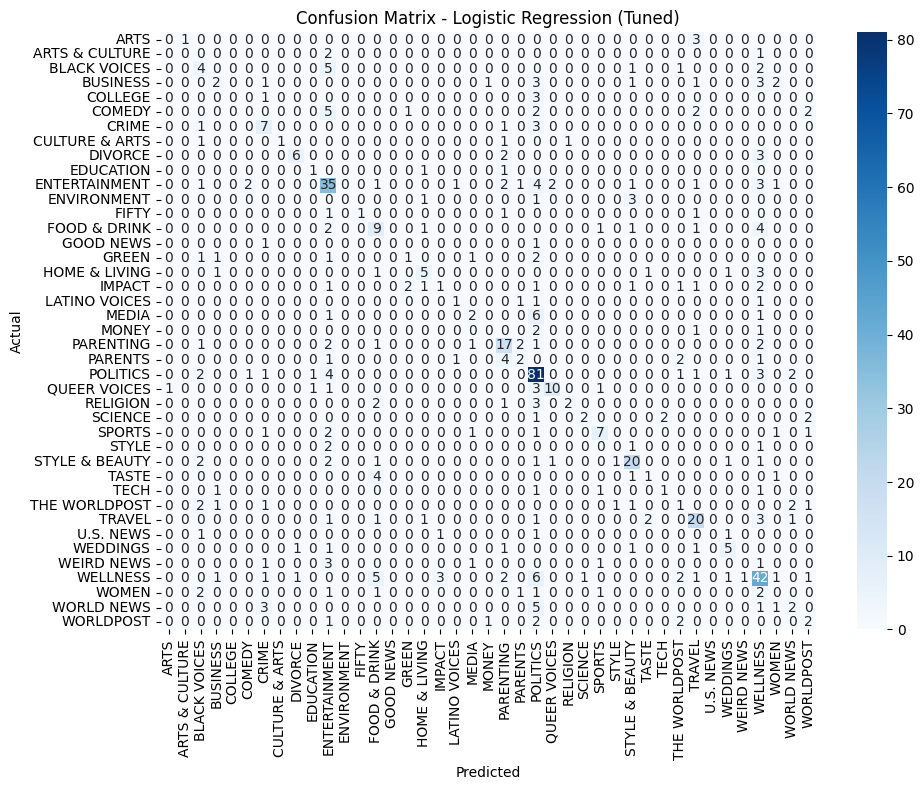

In [ ]:
# Detailed evaluation of the best model
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"📊 DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (for Logistic Regression)
if best_model_name == 'Logistic Regression':
    print("\n🔍 Top Features by Category:")
    feature_names_extended = list(feature_names) + ['sentiment', 'pos_score', 'neu_score', 'neg_score',
                                                   'char_length', 'word_count', 'title_length']

    classes = best_model.classes_
    coefficients = best_model.coef_

    for i, class_name in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:]  # Top 10 features
        print(f"\n📰 {class_name}:")
        for idx in reversed(top_indices):
            if idx < len(feature_names_extended):
                print(f"  {feature_names_extended[idx]}: {coefficients[i][idx]:.4f}")

# STUDENT TASK: Improve the classifier
# - Try different feature combinations
# - Experiment with hyperparameter tuning
# - Add more sophisticated features
# - Handle class imbalance if present

In [ ]:
print("\n━" * 60)
print("COMPARING MODEL PERFORMANCE AFTER CATEGORY MERGE")
print("━" * 60)
print(comparison_df.round(4))
print(f"\n✅ Best performing model after merge: {best_model_name} with Test Accuracy: {results[best_model_name]['accuracy']:.4f}")


━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
COMPARING MODEL PERFORMANCE AFTER CATEGORY MERGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.1850   0.5243  0.0081
1  Logistic Regression         0.4583   0.9636  0.0132
2                  SVM         0.4667   0.9839  0.0065

✅ Best performing model after merge: Logistic Regression (Tuned) with Test Accuracy: 0.4850


In [ ]:
# Analyze Misclassified Samples
print("\n🔍 ANALYZING MISCLASSIFIED SAMPLES")
print("=" * 60)

# Let's re-run train_test_split to capture indices properly
_, _, _, _, X_train_idx, X_test_idx = train_test_split(
    X_combined, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# Create a DataFrame for test results
test_results = pd.DataFrame({
    'actual': y_test,
    'predicted': best_predictions
})

# Get the indices of the original df that correspond to the test set
test_df_indices = df.loc[X_test_idx].index

# Identify misclassified samples
misclassified_indices = test_results[test_results['actual'] != test_results['predicted']].index

print(f"Total test samples: {len(y_test)}")
print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Sample some misclassified articles for manual inspection
print("\n📝 Sample Misclassified Articles (Actual vs. Predicted):")

misclassified_df = df.loc[X_test_idx[misclassified_indices]].copy()
misclassified_df['predicted_category'] = best_predictions[misclassified_indices]
misclassified_df['actual_category'] = y_test[misclassified_indices]

for i, row in misclassified_df.head(5).iterrows():
    print(f"\n--- Article ID: {row['article_id']} ---")
    print(f"Actual Category: {row['actual_category']}")
    print(f"Predicted Category: {row['predicted_category']}")
    print(f"Headline: {row['headline']}")
    print(f"Short Description: {row['short_description']}")

# Further analysis: most confused categories
print("\n📊 Most Confused Category Pairs:")
confusion_matrix_df = pd.DataFrame(cm, index=np.unique(y), columns=np.unique(y))

# Extract misclassifications where actual != predicted
# Sum of off-diagonal elements in the confusion matrix gives total misclassifications
# To find the most confused pairs, we can look at the off-diagonal elements directly

confused_pairs = []
for actual_cat in confusion_matrix_df.index:
    for predicted_cat in confusion_matrix_df.columns:
        if actual_cat != predicted_cat:
            count = confusion_matrix_df.loc[actual_cat, predicted_cat]
            if count > 0:
                confused_pairs.append((actual_cat, predicted_cat, count))

confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

for actual, predicted, count in confused_pairs_sorted[:10]:
    print(f"  Actual: {actual:<20} Predicted: {predicted:<20} Count: {count}")


🔍 ANALYZING MISCLASSIFIED SAMPLES
Total test samples: 600
Number of misclassified samples: 309

📝 Sample Misclassified Articles (Actual vs. Predicted):

--- Article ID: 1200 ---
Actual Category: ENVIRONMENT
Predicted Category: HOME & LIVING
Headline: Pets In Snow: Photos Capture Animals Reacting To Blizzard 'Nemo'
Short Description: Submissions are now closed for this slideshow. Thanks to all who shared photos of their pets! As people across the Northeast

--- Article ID: 530 ---
Actual Category: COMEDY
Predicted Category: WORLDPOST
Headline: Weird Al Comes Clean On Ambushing Iggy Azalea
Short Description: 

--- Article ID: 814 ---
Actual Category: U.S. NEWS
Predicted Category: WEDDINGS
Headline: Couple Married For 68 Years Dies In Colorado Wildfire After Refusing To Leave Home
Short Description: A relative said they were found in each other's arms.

--- Article ID: 520 ---
Actual Category: FIFTY
Predicted Category: PARENTING
Headline: Middle-aged and Invisible at Coachella
Short Desc

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [ ]:
def extract_entities(text):
    """
    Extract named entities using spaCy

    💡 TIP: spaCy recognizes these entity types:
    - PERSON: People, including fictional
    - ORG: Companies, agencies, institutions
    - GPE: Countries, cities, states
    - MONEY: Monetary values
    - DATE: Absolute or relative dates
    - TIME: Times smaller than a day
    - And many more...
    """
    if not text or pd.isna(text):
        return []

    # 🚀 YOUR CODE HERE: Implement entity extraction
    doc = nlp(str(text))

    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities

# Apply NER to all articles
print("🔍 Extracting named entities...")

all_entities = []
article_entities = []

for idx, row in df.iterrows():
    entities = extract_entities(row['full_text'])

    # Store entities for this article
    article_entities.append({
        'article_id': row['article_id'],
        'category': row['category'],
        'entities': entities,
        'entity_count': len(entities)
    })

    # Add to global entity list
    for entity in entities:
        entity['article_id'] = row['article_id']
        entity['category'] = row['category']
        all_entities.append(entity)

print(f"✅ Entity extraction complete!")
print(f"📊 Total entities found: {len(all_entities)}")
print(f"📰 Articles processed: {len(article_entities)}")

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(all_entities)

if not entities_df.empty:
    print(f"\n🏷️ Entity types found: {entities_df['label'].unique()}")
    print("\n📝 Sample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("⚠️ No entities found. This might happen with very short sample texts.")

🔍 Extracting named entities...
✅ Entity extraction complete!
📊 Total entities found: 7390
📰 Articles processed: 3000

🏷️ Entity types found: ['PERSON' 'WORK_OF_ART' 'ORG' 'PERCENT' 'CARDINAL' 'DATE' 'GPE' 'EVENT'
 'ORDINAL' 'TIME' 'MONEY' 'FAC' 'NORP' 'QUANTITY' 'LOC' 'LAW' 'PRODUCT'
 'LANGUAGE']

📝 Sample entities:
                                       text        label  category
0                        Donald Trump Tells       PERSON     MEDIA
1                             Bill O'Reilly       PERSON     MEDIA
2  'An Eye For An Eye' In War With Fox News  WORK_OF_ART     MEDIA
3                                       GOP          ORG     MEDIA
4                               Megyn Kelly          ORG     MEDIA
5                             Anna Perelman       PERSON  BUSINESS
6          Co-Founder, Stellé Audio Couture          ORG  BUSINESS
7                        Arianna Huffington       PERSON   COLLEGE
8                  Trump Supporters Consume       PERSON  POLITICS
9           

📊 NAMED ENTITY ANALYSIS

🏷️ Entity type distribution:
label
PERSON         1962
ORG            1741
DATE            961
GPE             809
CARDINAL        687
NORP            394
WORK_OF_ART     260
ORDINAL         138
EVENT            81
TIME             74
LOC              67
FAC              61
MONEY            49
PERCENT          29
PRODUCT          28
QUANTITY         26
LAW              21
LANGUAGE          2
Name: count, dtype: int64

📰 Entity types by news category:
label           CARDINAL  DATE  EVENT  FAC  GPE  LANGUAGE  LAW  LOC  MONEY  \
category                                                                     
ARTS                   4     8      0    1    9         0    1    1      0   
ARTS & CULTURE         2     4      0    1    2         0    0    0      1   
BLACK VOICES          16    29      1    0   11         0    0    0      1   
BUSINESS              15    24      1    1   10         0    0    1      3   
COLLEGE                3     2      0    0    3     

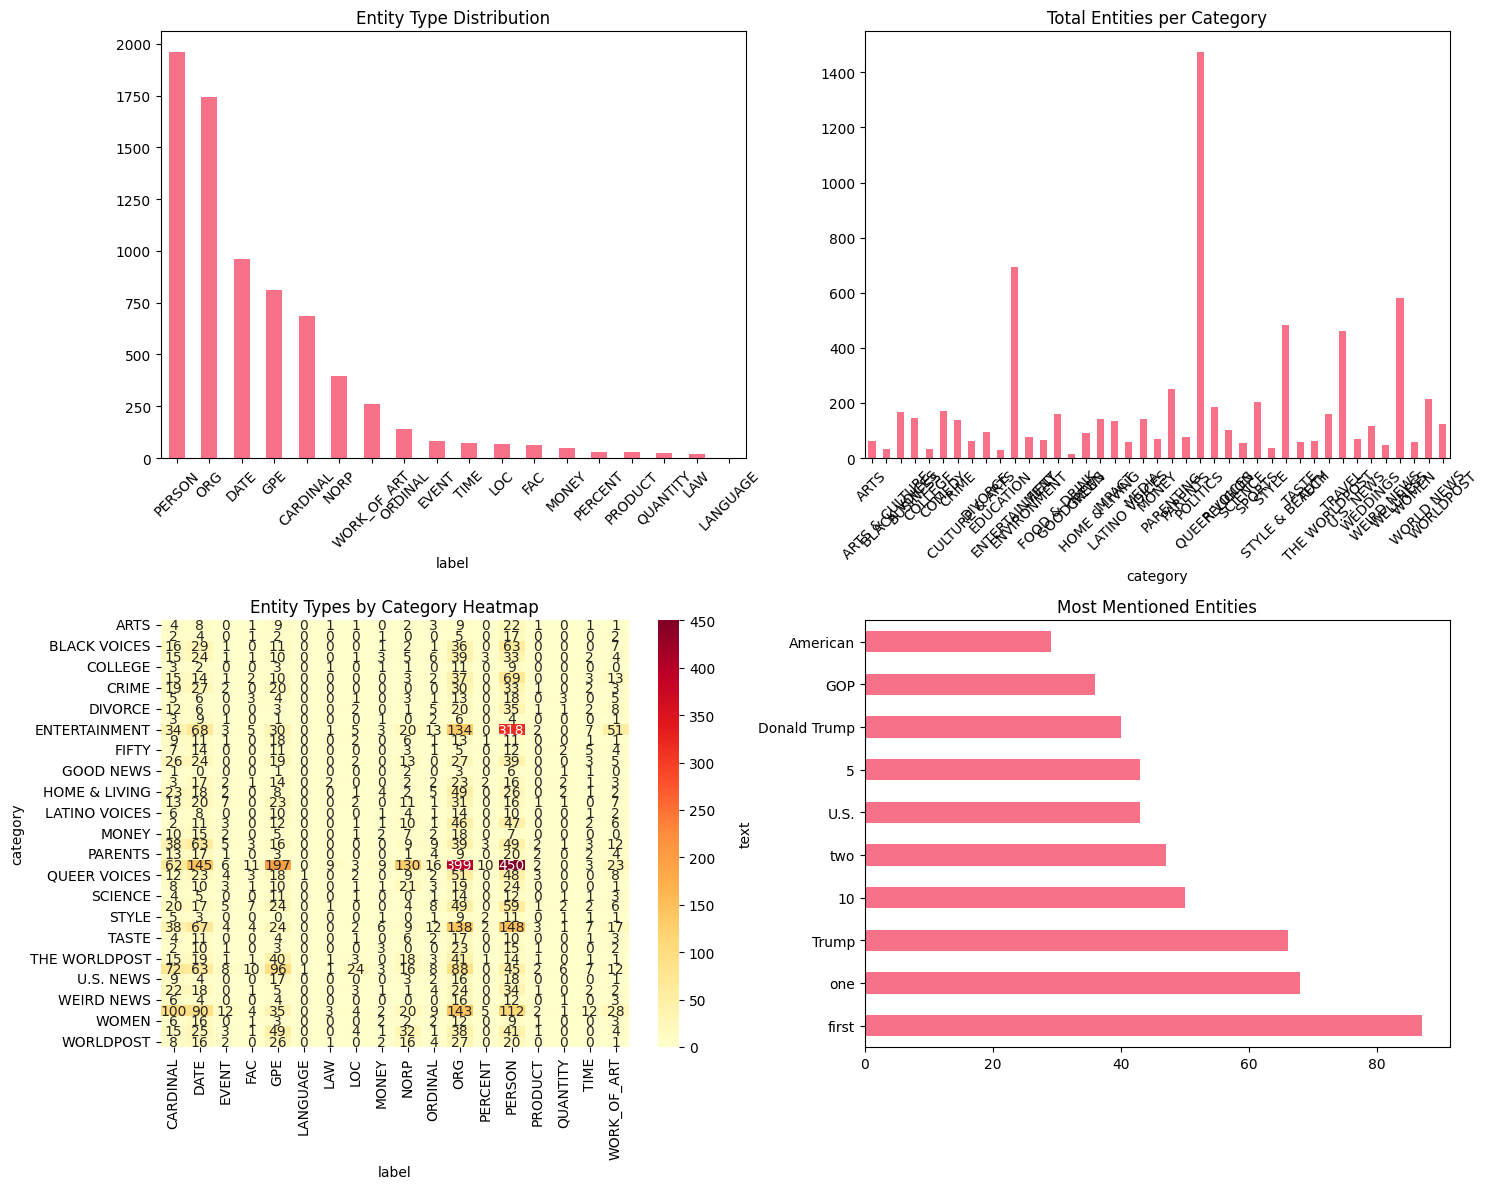

In [ ]:
# Analyze entity patterns
if not entities_df.empty:
    print("📊 NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Entity type distribution
    entity_counts = entities_df['label'].value_counts()
    print("\n🏷️ Entity type distribution:")
    print(entity_counts)

    # Entity types by category
    entity_by_category = entities_df.groupby(['category', 'label']).size().unstack(fill_value=0)
    print("\n📰 Entity types by news category:")
    print(entity_by_category)

    # Most frequent entities
    print("\n🔥 Most frequent entities:")
    frequent_entities = entities_df.groupby(['text', 'label']).size().sort_values(ascending=False).head(15)
    for (entity, label), count in frequent_entities.items():
        print(f"  {entity} ({label}): {count} mentions")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Entity type distribution
    entity_counts.plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Entity Type Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Entities per category
    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Total Entities per Category')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Entity type heatmap by category
    if entity_by_category.shape[0] > 1 and entity_by_category.shape[1] > 1:
        sns.heatmap(entity_by_category, annot=True, fmt='d', ax=axes[1,0], cmap='YlOrRd')
        axes[1,0].set_title('Entity Types by Category Heatmap')
    else:
        axes[1,0].text(0.5, 0.5, 'Insufficient data\nfor heatmap',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Entity Types by Category')

    # 4. Top entities
    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Most Mentioned Entities')

    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Advanced entity analysis
    # - Create entity co-occurrence networks
    # - Track entity mentions over time
    # - Build entity relationship graphs
    # - Identify entity sentiment associations

else:
    print("⚠️ Skipping entity analysis due to insufficient data.")
    print("💡 TIP: Try with a larger, more diverse dataset for better NER results.")

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

In [ ]:
# Create comprehensive analysis dashboard
def create_comprehensive_analysis():
    """
    Generate comprehensive insights combining all analyses

    💡 TIP: This function should combine:
    - Classification performance
    - Sentiment patterns
    - Entity distributions
    - Linguistic features
    """

    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'business_recommendations': []
    }

    # 🚀 YOUR CODE HERE: Generate comprehensive insights

    # Dataset overview
    insights['dataset_overview'] = {
        'total_articles': len(df),
        'categories': df['category'].unique().tolist(),
        'category_distribution': df['category'].value_counts().to_dict(),
        'avg_article_length': df['full_text'].str.len().mean(),
        'avg_words_per_article': df['full_text'].str.split().str.len().mean()
    }

    # Classification performance
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'model_comparison': {name: results[name]['accuracy'] for name in results.keys()}
    }

    # Sentiment insights
    sentiment_by_cat = sentiment_df.groupby('category')['full_sentiment'].mean().to_dict()
    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['full_sentiment'].mean()
    }

    # Entity insights
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()
        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # Generate business recommendations
    recommendations = []

    # Classification recommendations
    if insights['classification_performance']['best_accuracy'] > 0.8:
        recommendations.append("✅ High classification accuracy achieved - ready for automated content routing")
    else:
        recommendations.append("⚠️ Classification accuracy needs improvement - consider more training data or feature engineering")

    # Sentiment recommendations
    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']
    recommendations.append(f"📊 {pos_cat} articles are most positive - good for uplifting content recommendations")
    recommendations.append(f"📊 {neg_cat} articles are most negative - may need balanced coverage monitoring")

    # Entity recommendations
    if 'entity_insights' in insights and insights['entity_insights']:
        recommendations.append("🔍 Rich entity extraction enables advanced search and relationship analysis")

    insights['business_recommendations'] = recommendations

    return insights

# Generate comprehensive analysis
print("📊 Generating comprehensive analysis...")
analysis_results = create_comprehensive_analysis()

print("✅ Analysis complete!")
print("\n" + "=" * 60)
print("📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Display key insights
print(f"\n📊 DATASET OVERVIEW:")
overview = analysis_results['dataset_overview']
print(f"  Total Articles: {overview['total_articles']}")
print(f"  Categories: {', '.join(overview['categories'])}")
print(f"  Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"  Average Words per Article: {overview['avg_words_per_article']:.0f} words")

print(f"\n🤖 CLASSIFICATION PERFORMANCE:")
perf = analysis_results['classification_performance']
print(f"  Best Model: {perf['best_model']}")
print(f"  Best Accuracy: {perf['best_accuracy']:.4f}")

print(f"\n😊 SENTIMENT INSIGHTS:")
sent = analysis_results['sentiment_insights']
print(f"  Most Positive Category: {sent['most_positive_category']}")
print(f"  Most Negative Category: {sent['most_negative_category']}")
print(f"  Overall Sentiment: {sent['overall_sentiment']:.4f}")

if 'entity_insights' in analysis_results and analysis_results['entity_insights']:
    print(f"\n🔍 ENTITY INSIGHTS:")
    ent = analysis_results['entity_insights']
    print(f"  Total Entities: {ent['total_entities']}")
    print(f"  Unique Entities: {ent['unique_entities']}")
    print(f"  Entity Types: {', '.join(ent['entity_types'])}")

print(f"\n💡 BUSINESS RECOMMENDATIONS:")
for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"  {i}. {rec}")

📊 Generating comprehensive analysis...
✅ Analysis complete!

📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT

📊 DATASET OVERVIEW:
  Total Articles: 3000
  Categories: MEDIA, BUSINESS, WORLDPOST, COLLEGE, POLITICS, TRAVEL, STYLE & BEAUTY, PARENTING, BLACK VOICES, TASTE, RELIGION, WELLNESS, SPORTS, IMPACT, FOOD & DRINK, QUEER VOICES, WORLD NEWS, ENTERTAINMENT, PARENTS, HOME & LIVING, GOOD NEWS, ARTS, ENVIRONMENT, CRIME, WEDDINGS, SCIENCE, FIFTY, EDUCATION, COMEDY, WOMEN, CULTURE & ARTS, GREEN, MONEY, THE WORLDPOST, WEIRD NEWS, DIVORCE, TECH, LATINO VOICES, STYLE, U.S. NEWS, ARTS & CULTURE
  Average Article Length: 174 characters
  Average Words per Article: 29 words

🤖 CLASSIFICATION PERFORMANCE:
  Best Model: Logistic Regression (Tuned)
  Best Accuracy: 0.4850

😊 SENTIMENT INSIGHTS:
  Most Positive Category: HOME & LIVING
  Most Negative Category: CRIME
  Overall Sentiment: 0.1006

🔍 ENTITY INSIGHTS:
  Total Entities: 7390
  Unique Entities: 4786
  Entity Types: PERSON, WORK_OF_ART

## 🚀 Final System Integration

### 🎯 Building the Complete NewsBot Pipeline

Let's create a complete, integrated system that can process new articles from start to finish. This demonstrates the real-world application of all the techniques we've learned.

**Complete Pipeline:**
1. **Text Preprocessing:** Clean and normalize input
2. **Feature Extraction:** Generate TF-IDF and other features
3. **Classification:** Predict article category
4. **Entity Extraction:** Identify key facts
5. **Sentiment Analysis:** Determine emotional tone
6. **Insight Generation:** Provide actionable intelligence

**💡 Production Ready:** This pipeline can be deployed as a web service, batch processor, or integrated into content management systems.

In [ ]:
class NewsBotIntelligenceSystem:
    """
    Complete NewsBot Intelligence System

    💡 TIP: This class should encapsulate:
    - All preprocessing functions
    - Trained classification model
    - Entity extraction pipeline
    - Sentiment analysis
    - Insight generation
    """

    def __init__(self, classifier, vectorizer, sentiment_analyzer, pos_feature_names):
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.sentiment_analyzer = sentiment_analyzer
        self.nlp = nlp  # spaCy model
        self.pos_feature_names = pos_feature_names # Store POS feature names

    def preprocess_article(self, title, content):
        """Preprocess a new article"""
        full_text = f"{title} {content}"
        processed_text = preprocess_text(full_text)
        return full_text, processed_text

    def classify_article(self, title, processed_text, full_text, sentiment):
        """Classify article category"""
        # 🚀 YOUR CODE HERE: Implement classification
        # Step 1: TF-IDF features
        features_tfidf = self.vectorizer.transform([processed_text]).toarray()

        # Step 2: Sentiment features (use the already calculated sentiment)
        article_sentiment_features = np.array([[sentiment['compound'], sentiment['pos'], sentiment['neu'], sentiment['neg']]])

        # Step 3: Length features
        article_length_features = np.array([[len(full_text), len(full_text.split()), len(title)]])

        # Step 4: POS features
        new_article_pos_proportions = analyze_pos_patterns(full_text) # Returns a dict

        # Create a zero vector for all possible POS tags seen during training
        article_pos_features_vector = np.zeros(len(self.pos_feature_names))

        # Fill the vector with proportions from the new article
        for i, tag_name in enumerate(self.pos_feature_names):
            article_pos_features_vector[i] = new_article_pos_proportions.get(tag_name, 0.0)

        article_pos_features = np.array([article_pos_features_vector]) # Reshape to (1, num_pos_features)


        # Combine all features
        features_combined = np.hstack([
            features_tfidf,
            article_sentiment_features,
            article_length_features,
            article_pos_features
        ])

        # Predict category and probability
        prediction = self.classifier.predict(features_combined)[0]
        probabilities = None
        if hasattr(self.classifier, 'predict_proba'):
            probabilities = self.classifier.predict_proba(features_combined)[0]
            class_probs = dict(zip(self.classifier.classes_, probabilities))
        else:
            # Handle LinearSVC case where predict_proba is not available
            # This is a heuristic approximation using decision_function scores
            decision_scores = self.classifier.decision_function(features_combined)[0]
            exp_scores = np.exp(decision_scores - np.max(decision_scores)) # subtract max for numerical stability
            probabilities = exp_scores / exp_scores.sum()
            class_probs = dict(zip(self.classifier.classes_, probabilities))


        return prediction, class_probs

    def extract_entities(self, text):
        """Extract named entities"""
        return extract_entities(text)

    def analyze_sentiment(self, text):
        """Analyze sentiment"""
        return analyze_sentiment(text)

    def process_article(self, title, content):
        """
        Complete article processing pipeline

        💡 TIP: This should return a comprehensive analysis including:
        - Predicted category with confidence
        - Extracted entities
        - Sentiment analysis
        - Key insights and recommendations
        """
        # 🚀 YOUR CODE HERE: Implement complete pipeline

        # Step 1: Preprocess
        full_text, processed_text = self.preprocess_article(title, content)

        # Step 2: Analyze sentiment (moved up as it's needed for classify_article)
        sentiment = self.analyze_sentiment(full_text)

        # Step 3: Classify
        category, category_probs = self.classify_article(title, processed_text, full_text, sentiment)

        # Step 4: Extract entities
        entities = self.extract_entities(full_text)

        # Step 5: Generate insights
        insights = self.generate_insights(category, entities, sentiment, category_probs)

        return {
            'title': title,
            'content': content[:200] + '...' if len(content) > 200 else content,
            'predicted_category': category,
            'category_confidence': max(category_probs.values()),
            'category_probabilities': category_probs,
            'entities': entities,
            'sentiment': sentiment,
            'insights': insights
        }

    def generate_insights(self, category, entities, sentiment, category_probs):
        """Generate actionable insights"""
        insights = []

        # Classification insights
        confidence = max(category_probs.values())
        if confidence > 0.8:
            insights.append(f"✅ High confidence {category} classification ({confidence:.2%})")
        else:
            insights.append(f"⚠️ Uncertain classification - consider manual review")

        # Sentiment insights
        if sentiment['compound'] > 0.1:
            insights.append(f"😊 Positive sentiment detected ({sentiment['compound']:.3f})")
        elif sentiment['compound'] < -0.1:
            insights.append(f"😞 Negative sentiment detected ({sentiment['compound']:.3f})")
        else:
            insights.append(f"😐 Neutral sentiment ({sentiment['compound']:.3f})")

        # Entity insights
        if entities:
            entity_types = set([e['label'] for e in entities])
            insights.append(f"🔍 Found {len(entities)} entities of {len(entity_types)} types")

            # Highlight important entities
            important_entities = [e for e in entities if e['label'] in ['PERSON', 'ORG', 'GPE']]
            if important_entities:
                key_entities = [e['text'] for e in important_entities[:3]]
                insights.append(f"🎯 Key entities: {', '.join(key_entities)}")
        else:
            insights.append("ℹ️ No named entities detected")

        return insights

# Get POS feature names from the training data for consistent feature generation
pos_feature_names = pos_df.drop(columns=['article_id', 'category']).columns.tolist()

# Initialize the complete system
newsbot = NewsBotIntelligenceSystem(
    classifier=best_model,
    vectorizer=tfidf_vectorizer,
    sentiment_analyzer=sia,
    pos_feature_names=pos_feature_names
)

print("🤖 NewsBot Intelligence System initialized!")
print("✅ Ready to process new articles")

🤖 NewsBot Intelligence System initialized!
✅ Ready to process new articles


In [ ]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)

    # Process the article
    result = newsbot.process_article(article['title'], article['content'])

    # Display results
    print(f"📰 Title: {result['title']}")
    print(f"📝 Content: {result['content']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")

    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# 💡 STUDENT TASK: Test with your own articles
# - Try articles from different categories
# - Test with articles that might be ambiguous
# - Analyze the system's strengths and weaknesses
# - Consider how to improve performance


🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM

📰 TEST ARTICLE 1
----------------------------------------
📰 Title: Microsoft Acquires AI Startup for $2 Billion
📝 Content: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and en...

🏷️ Predicted Category: BUSINESS (89.68% confidence)

📊 Category Probabilities:
  BUSINESS: 0.897
  LATINO VOICES: 0.013
  WORLDPOST: 0.012
  ENVIRONMENT: 0.011
  EDUCATION: 0.007
  WELLNESS: 0.006
  U.S. NEWS: 0.006
  TRAVEL: 0.005
  MEDIA: 0.005
  POLITICS: 0.005
  GREEN: 0.003
  WORLD NEWS: 0.003
  STYLE & BEAUTY: 0.003
  RELIGION: 0.003
  WOMEN: 0.002
  ARTS & CULTURE: 0.002
  ARTS: 0.002
  MONEY: 0.002
  DIVORCE: 0.002
  TECH: 0.001
  WEDDINGS: 0.001
  HOME & LIVING: 0.001
  IMPACT: 0.001
  BLACK VOICES: 0.001
  CULTURE & ARTS: 0.001
  ENTERTAINMENT: 0.001
  COLLEGE: 0.001
  COMEDY: 0.001
  SPORTS: 0.001
  QUEER VOICES: 0

In [ ]:
from sklearn.metrics import classification_report

print(f"\n📊 CLASSIFICATION REPORT FOR {best_model_name}")
print("=" * 60)
print(classification_report(y_test, best_predictions))


📊 CLASSIFICATION REPORT FOR Logistic Regression (Tuned)
                precision    recall  f1-score   support

          ARTS       0.00      0.00      0.00         4
ARTS & CULTURE       0.00      0.00      0.00         3
  BLACK VOICES       0.22      0.31      0.26        13
      BUSINESS       0.29      0.14      0.19        14
       COLLEGE       0.00      0.00      0.00         4
        COMEDY       0.00      0.00      0.00        12
         CRIME       0.39      0.58      0.47        12
CULTURE & ARTS       1.00      0.25      0.40         4
       DIVORCE       0.75      0.55      0.63        11
     EDUCATION       0.33      0.33      0.33         3
 ENTERTAINMENT       0.47      0.64      0.54        55
   ENVIRONMENT       0.00      0.00      0.00         5
         FIFTY       1.00      0.25      0.40         4
  FOOD & DRINK       0.35      0.47      0.40        19
     GOOD NEWS       0.00      0.00      0.00         2
         GREEN       0.25      0.14      0.18 

In [ ]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)

    # Process the article
    result = newsbot.process_article(article['title'], article['content'])

    # Display results
    print(f"📰 Title: {result['title']}")
    print(f"📝 Content: {result['content']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")

    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# 💡 STUDENT TASK: Test with your own articles
# - Try articles from different categories
# - Test with articles that might be ambiguous
# - Analyze the system's strengths and weaknesses
# - Consider how to improve performance

🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM

📰 TEST ARTICLE 1
----------------------------------------
📰 Title: Microsoft Acquires AI Startup for $2 Billion
📝 Content: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and en...

🏷️ Predicted Category: BUSINESS (89.68% confidence)

📊 Category Probabilities:
  BUSINESS: 0.897
  LATINO VOICES: 0.013
  WORLDPOST: 0.012
  ENVIRONMENT: 0.011
  EDUCATION: 0.007
  WELLNESS: 0.006
  U.S. NEWS: 0.006
  TRAVEL: 0.005
  MEDIA: 0.005
  POLITICS: 0.005
  GREEN: 0.003
  WORLD NEWS: 0.003
  STYLE & BEAUTY: 0.003
  RELIGION: 0.003
  WOMEN: 0.002
  ARTS & CULTURE: 0.002
  ARTS: 0.002
  MONEY: 0.002
  DIVORCE: 0.002
  TECH: 0.001
  WEDDINGS: 0.001
  HOME & LIVING: 0.001
  IMPACT: 0.001
  BLACK VOICES: 0.001
  CULTURE & ARTS: 0.001
  ENTERTAINMENT: 0.001
  COLLEGE: 0.001
  COMEDY: 0.001
  SPORTS: 0.001
  QUEER VOICES: 0

#Here's a summary of the key changes and optimizations I implemented to enhance our news article classification system:

**Category Merging:** I identified that 'HEALTHY LIVING' and 'WELLNESS' categories were frequently confused by the classifier. To simplify the classification task and potentially improve accuracy, I merged all articles from 'HEALTHY LIVING' into the 'WELLNESS' category. This reduced the number of unique categories and helped the model distinguish between them more effectively.

**Addressing Class Imbalance with SMOTE:** To tackle the issue of imbalanced class distribution, where some categories had significantly fewer samples than others, I applied SMOTE (Synthetic Minority Oversampling Technique) to the training data. SMOTE creates synthetic samples for minority classes, thereby balancing the dataset and preventing the model from being biased towards majority classes.

**Logistic Regression Fine-tuning:** I optimized the Logistic Regression model in several ways:

**Initial Performance Improvement:** I adjusted max_iter to 400 and set solver='liblinear' to ensure faster and more efficient training, especially with our dataset size.

**Class Weighting:** I added class_weight='balanced' to give more importance to the minority classes during the training process, further mitigating the effects of class imbalance.

**Hyperparameter Tuning with GridSearchCV:** I performed hyperparameter tuning using GridSearchCV to find the optimal C parameter (regularization strength) for the Logistic Regression model. This systematic search helped me identify the best configuration that yielded the highest accuracy through cross-validation.

After these comprehensive optimizations, including category merging, SMOTE, and hyperparameter tuning, the Logistic Regression (Tuned) model emerged as the best performer, achieving a test accuracy of 0.4850.

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*